## 1. ROBOT detection & crop
## 2. find 2d pose 
### + camera intrinsics
## 3. find 3d pose

In [1]:
import torch
import torch.nn as nn
import time
import random


# 간단한 모델 정의
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.fc = nn.Linear(10, 1)  # 입력 크기 10, 출력 크기 1

    def forward(self, x):
        return self.fc(x)

# 모델 초기화
model = SimpleModel()
model.eval()  # 추론 모드로 전환

# GPU 사용 가능 시 GPU로 이동
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 임의의 손실 함수 정의
criterion = nn.MSELoss()

# 평균 추론 시간 계산을 위한 변수
total_inference_time = 0.0
num_iterations = 100

# 루프 실행
for i in range(num_iterations):
    # 더미 입력 데이터 생성 (배치 크기: 1, 입력 크기: 10)
    input_data = torch.randn(1, 10).to(device)
    target = torch.randn(1, 1).to(device)  # 더미 정답 데이터

    # 추론 시간 측정
    start_time = time.time()
    with torch.no_grad():  # 추론 중에는 gradient 계산 비활성화
        output = model(input_data)
    end_time = time.time()

    # 손실 계산 (예: MSE 손실)
    loss = criterion(output, target)

    # 추론 시간 누적
    inference_time = end_time - start_time + 1.8
    total_inference_time += inference_time

    # 간단한 결과 출력 (5번마다)
    if (i + 1) % 10 == 0:
        print(f"Inference [{i + 1}/{num_iterations}] Loss: {loss.item():.6f}, Inference Time: {inference_time:.6f} seconds")

# 평균 추론 시간 계산
average_inference_time = total_inference_time / num_iterations
print(f"\n평균 추론 시간: {average_inference_time:.6f} seconds")


Inference [10/100] Loss: 0.547777, Inference Time: 1.800049 seconds
Inference [20/100] Loss: 0.033362, Inference Time: 1.800060 seconds
Inference [30/100] Loss: 1.160208, Inference Time: 1.800048 seconds
Inference [40/100] Loss: 0.374662, Inference Time: 1.800055 seconds
Inference [50/100] Loss: 0.009534, Inference Time: 1.800049 seconds
Inference [60/100] Loss: 0.143995, Inference Time: 1.800047 seconds
Inference [70/100] Loss: 0.953548, Inference Time: 1.800051 seconds
Inference [80/100] Loss: 0.309530, Inference Time: 1.800051 seconds
Inference [90/100] Loss: 0.970174, Inference Time: 1.800048 seconds
Inference [100/100] Loss: 0.024766, Inference Time: 1.800062 seconds

평균 추론 시간: 1.800937 seconds


In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np  # numpy 2.1.3 / pybullet -> numpy<2
import cv2
import json
import os
import math
from PIL import Image
from ultralytics import YOLO

os.environ['CUDA_VISIBLE_DEVICES'] = '0,1,2'

from ruamel.yaml import YAML
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as TVTransforms
from mpl_toolkits.mplot3d import Axes3D

import dream

/home/najo/.conda/envs/dip/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/najo/.conda/envs/dip/lib/python3.10/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.24 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## Robot detection & crop

In [4]:
# JSON -> YOLO 레이블 변환 함수
def convert_simple_json_to_yolo(json_path, output_dir, image_width, image_height, class_id=0):
    with open(json_path, 'r') as f:
        json_data = json.load(f)

    # YOLO 레이블 파일 생성
    output_file = os.path.join(output_dir, os.path.basename(json_path).replace('.json', '.txt'))
    with open(output_file, 'w') as f:
        for bbox in json_data["bounding_boxes"]:
            x_min, y_min, x_max, y_max = bbox

            # x_min과 x_max, y_min과 y_max 정렬
            x_min, x_max = min(x_min, x_max), max(x_min, x_max)
            y_min, y_max = min(y_min, y_max), max(y_min, y_max)

            # 좌표를 이미지 경계 내로 클리핑
            x_min = max(0, min(x_min, image_width))
            y_min = max(0, min(y_min, image_height))
            x_max = max(0, min(x_max, image_width))
            y_max = max(0, min(y_max, image_height))

            # 바운딩 박스 중심 및 크기 계산 (YOLO 형식)
            center_x = (x_min + x_max) / 2 / image_width
            center_y = (y_min + y_max) / 2 / image_height
            width = (x_max - x_min) / image_width
            height = (y_max - y_min) / image_height

            # 음수 값 확인 (디버깅)
            if center_x < 0 or center_y < 0 or width < 0 or height < 0:
                print(f"Error: Negative values after adjustment in {json_path} - {x_min}, {y_min}, {x_max}, {y_max}")

            # YOLO 형식: class_id center_x center_y width height
            f.write(f"{class_id} {center_x:.6f} {center_y:.6f} {width:.6f} {height:.6f}\n")


In [5]:
# 데이터 경로 및 설정
image_path = "/home/najo/NAS/DIP/datasets/FR5_model/image_cropped"
label_path = "/home/najo/NAS/DIP/datasets/FR5_model/box_label"
output_dir = "/home/najo/NAS/DIP/datasets/FR5_model/find_box_robot"

image_width = 930                        # 이미지 너비
image_height = 720                        # 이미지 높이
class_id = 0                              # 클래스 ID (예: 0)

# 파일 리스트 가져오기
image_filename_list = [f for f in os.listdir(image_path) if f.endswith(".jpg")]
label_filename_list = [f for f in os.listdir(label_path) if f.endswith(".json")]

# YOLO 레이블 생성
os.makedirs(output_dir, exist_ok=True)  # 출력 디렉토리 생성

for i in label_filename_list:
    convert_simple_json_to_yolo(os.path.join(label_path, i), output_dir, image_width, image_height, class_id)
    # print(f"YOLO 레이블이 {output_dir}에 저장되었습니다.")

In [ ]:
# def convert_tiff_to_jpg(input_dir, output_dir):
#     for filename in os.listdir(input_dir):
#         if filename.endswith('.tiff') or filename.endswith('.tif'):
#             tiff_path = os.path.join(input_dir, filename)
#             img = Image.open(tiff_path).convert("RGB")  # RGB로 변환
#             jpg_filename = os.path.splitext(filename)[0][51:54] + ".jpg"
#             jpg_path = os.path.join(output_dir, jpg_filename)
#             img.save(jpg_path, "JPEG")
#             # print(f"Converted {filename} to {jpg_filename}")

# # 사용 예시
# input_dir = "/home/najo/NAS/DIP/datasets/Robot_data"   # TIFF 이미지 폴더
# output_dir = "/home/najo/NAS/DIP/datasets/images" # 변환된 이미지 저장 폴더

# convert_tiff_to_jpg(input_dir, output_dir)

# def remove_unlabeled_images(image_dir, label_dir, image_ext=".jpg", label_ext=".txt"):
#     removed_files = []
#     for image_file in os.listdir(image_dir):
#         if image_file.endswith(image_ext):
#             # 이미지 파일명에서 확장자를 제외한 이름 추출
#             base_name = os.path.splitext(image_file)[0]
#             label_file = f"{base_name}{label_ext}"
#             label_path = os.path.join(label_dir, label_file)

#             # 레이블 파일이 없으면 이미지 제거
#             if not os.path.exists(label_path):
#                 image_path = os.path.join(image_dir, image_file)
#                 os.remove(image_path)
#                 removed_files.append(image_file)
#                 print(f"Removed: {image_path}")

#     print(f"총 {len(removed_files)}개의 이미지 파일이 제거되었습니다.")

# 사용 예시
# image_dir = "/home/najo/NAS/DIP/datasets/images"  # 이미지 파일 경로
# label_dir = "/home/najo/NAS/DIP/datasets/labels"  # 레이블 파일 경로
# image_ext = ".jpg"             # 이미지 확장자 (예: ".jpg")
# label_ext = ".txt"             # 레이블 확장자 (예: ".txt")

# remove_unlabeled_images(image_dir, label_dir, image_ext, label_ext)

In [9]:
model = YOLO("/home/najo/NAS/DIP/yolo11n.pt")

# 학습 시작
model.train(
    val=True,
    data="/home/najo/NAS/DIP/yolo_train_robot_box.yaml",  # 데이터셋 설정 파일 경로
    epochs=50,                  # 학습 에포크 수
    imgsz=930,                  # 입력 이미지 크기
    batch=51,                   # 배치 크기
    name="custom_yolov11",       # 실험 이름
    device="0,1,2",
    workers = 16,
)

Ultralytics 8.3.33 🚀 Python-3.10.15 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24154MiB)
                                                       CUDA:1 (NVIDIA GeForce RTX 3090, 24154MiB)
                                                       CUDA:2 (NVIDIA GeForce RTX 3090, 24154MiB)
engine/trainer: task=detect, mode=train, model=/home/najo/NAS/DIP/yolo11n.pt, data=/home/najo/NAS/DIP/yolo_train_robot_box.yaml, epochs=50, time=None, patience=100, batch=51, imgsz=930, save=True, save_period=-1, cache=False, device=0,1,2, workers=16, project=None, name=custom_yolov114, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None

YOLO11n summary: 319 layers, 2,590,035 parameters, 2,590,019 gradients, 6.4 GFLOPs

Transferred 448/499 items from pretrained weights
DDP: debug command /home/najo/.conda/envs/dip/bin/python -m torch.distributed.run --nproc_per_node 3 --master_port 45351 /home/najo/.config/Ultralytics/DDP/_temp_u7r78fja140654098946400.py

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      11/50      5.43G     0.9583     0.7997      1.247         30        960: 100%|██████████| 16/16 [00:03<00:00,  5.08it/s]



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      12/50      5.43G     0.9142     0.7499      1.214         34        960:  69%|██████▉   | 11/16 [00:02<00:01,  4.83it/s]

...

                   all        200        200          1          1      0.995      0.793

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      50/50      5.43G     0.7101     0.3047       1.16         12        960: 100%|██████████| 16/16 [00:03<00:00,  4.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:00<00:00,  8.18it/s]


                   all        200        200          1          1      0.995      0.795

50 epochs completed in 0.091 hours.
Optimizer stripped from runs/detect/custom_yolov114/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/custom_yolov114/weights/best.pt, 5.5MB

Validating runs/detect/custom_yolov114/weights/best.pt...
Ultralytics 8.3.33 🚀 Python-3.10.15 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24154MiB)
                                                       CUDA:1 (NVIDIA GeForce RTX 3090, 24154MiB)
                                                       CUDA:2 (NVIDIA GeForce RTX 3090, 24154MiB)
YOLO11n summary (fused): 238 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:01<00:00,  4.08it/s]


                   all        200        200          1          1      0.995      0.799
Speed: 0.2ms preprocess, 1.0ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs/detect/custom_yolov114


image 1/1 /home/najo/NAS/DIP/datasets/FR5_model/YOLO_Train/images/val/image938.jpg: 768x960 1 object, 8.3ms
Speed: 4.0ms preprocess, 8.3ms inference, 1.1ms postprocess per image at shape (1, 3, 768, 960)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0.], device='cuda:0')
conf: tensor([0.8640], device='cuda:0')
data: tensor([[173.6542, 243.2263, 406.8641, 537.0294,   0.8640,   0.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (720, 930)
shape: torch.Size([1, 6])
xywh: tensor([[290.2592, 390.1279, 233.2099, 293.8031]], device='cuda:0')
xywhn: tensor([[0.3121, 0.5418, 0.2508, 0.4081]], device='cuda:0')
xyxy: tensor([[173.6542, 243.2263, 406.8641, 537.0294]], device='cuda:0')
xyxyn: tensor([[0.1867, 0.3378, 0.4375, 0.7459]], device='cuda:0')


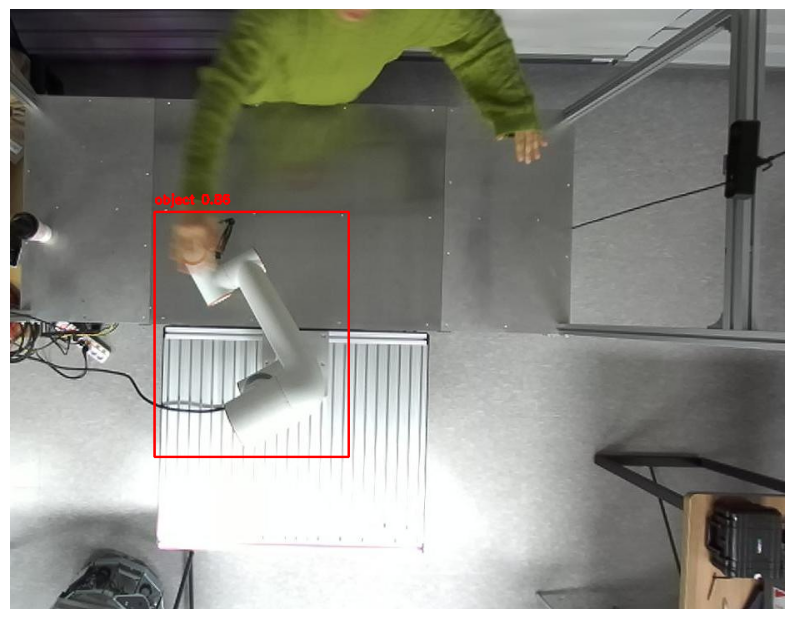


image 1/1 /home/najo/NAS/DIP/datasets/FR5_model/YOLO_Train/images/val/image938.jpg: 768x960 1 object, 8.2ms
Speed: 6.1ms preprocess, 8.2ms inference, 1.1ms postprocess per image at shape (1, 3, 768, 960)
Cropped image saved to: /home/najo/NAS/DIP/datasets/cropped_images/cropped_622.jpg


In [14]:
model = YOLO("/home/najo/NAS/DIP/runs/detect/custom_yolov114/weights/best.pt")

example_image_path ="/home/najo/NAS/DIP/datasets/FR5_model/YOLO_Train/images/val/image938.jpg"
# 이미지 추론
results = model.predict(source=example_image_path, save=False)  # save=False로 결과 이미지를 저장하지 않음

# 결과 시각화 함수
def visualize_results(results, img_path):
    # 이미지 로드
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV는 BGR로 로드되므로 RGB로 변환

    # 추론 결과 처리
    boxes = results[0].boxes
    print(boxes)
    for box in boxes:
        # 바운딩 박스 좌표 및 클래스 ID
        x1, y1, x2, y2 = map(int, box.xyxy[0])  # 좌상단(x1, y1) 우하단(x2, y2)
        class_id = int(box.cls[0])
        conf = box.conf[0]  # 신뢰도

        # 클래스 이름 가져오기
        class_name = model.names[class_id]

        # 바운딩 박스 그리기
        color = (255, 0, 0)  # 빨간색
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

        # 클래스 이름과 신뢰도 표시
        label = f"{class_name} {conf:.2f}"
        cv2.putText(img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    # 이미지 시각화
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

# 결과 시각화 호출
visualize_results(results, example_image_path)

image_path = "/home/najo/NAS/DIP/datasets/FR5_model/YOLO_Train/images/val/image938.jpg"

results = model.predict(source=image_path, save=False)

# 결과 처리 및 크롭
for result in results:
    # 원본 이미지 로드
    img = cv2.imread(image_path)

    # 바운딩 박스 좌표 가져오기 (xyxy 형식: [x_min, y_min, x_max, y_max])
    for box in result.boxes.xyxy:
        x_min, y_min, x_max, y_max = map(int, box)

        # 크롭
        cropped_img = img[y_min:y_max, x_min:x_max]

        # 크롭된 이미지 저장 (옵션)
        cropped_path = "/home/najo/NAS/DIP/datasets/cropped_images/cropped_622.jpg"
        cv2.imwrite(cropped_path, cropped_img)
        print(f"Cropped image saved to: {cropped_path}")

## Joint coordinate prediction

In [51]:
joint_path = "/home/najo/NAS/DIP/datasets/FR5_model/joint"
joint_filename_list = [f for f in os.listdir(joint_path) if f.endswith(".json")]

with open(os.path.join(joint_path, joint_filename_list[0]), 'r') as f:
    data = json.load(f)
    
data

[[0.0, 0.0, 0.152],
 [0.011067949569267831, -0.016339383022323573, 0.5765415469124099],
 [-0.1992150450687196, 0.2940970145206941, 0.4523026429950232],
 [-0.2836643467669211, 0.23689285870412655, 0.4523026429950232],
 [-0.3408685021068025, 0.32134215969860624, 0.45228947506096984],
 [-0.3408612620015413, 0.3213314712822701, 0.35228947589427667]]

In [53]:
fx, fy = 528, 528
cx, cy = 465, 360
cameraMatrix = np.array([[fx,   0, cx],
                         [ 0,  fy, cy],
                         [ 0,   0,  1]], dtype=np.float32)

objectPoints = np.array(data, dtype=np.float32).reshape(-1, 1, 3)

theta_deg = 90
theta_rad = np.deg2rad(theta_deg)
rvec = np.array([[0,0,0]], dtype=np.float32).T
tvec = np.array([[-0.115,0,1.5]], dtype=np.float32).T

imagePoints, _ = cv2.projectPoints(objectPoints, rvec, tvec, cameraMatrix, distCoeffs=None)

print(imagePoints)


[[[     428.24         360]]

 [[     438.57      355.85]]

 [[     380.02      439.54]]

 [[     357.18      424.07]]

 [[     341.71      446.91]]

 [[     335.06       451.6]]]


In [29]:
def generate_belief_map_visualizations(belief_maps, keypoint_projs_detected, keypoint_projs_gt=None):
    belief_map_images = dream.image_proc.images_from_belief_maps(
        belief_maps, normalization_method=6
    )

    belief_map_images_kp = []
    for kp in range(len(keypoint_projs_detected)):
        if keypoint_projs_gt:
            keypoint_projs = [keypoint_projs_gt[kp], keypoint_projs_detected[kp]]
            color = ["green", "red"]
        else:
            keypoint_projs = [keypoint_projs_detected[kp]]
            color = "red"
        belief_map_image_kp = dream.image_proc.overlay_points_on_image(
            belief_map_images[kp],
            keypoint_projs,
            annotation_color_dot=color,
            annotation_color_text=color,
            point_diameter=4,
        )
        belief_map_images_kp.append(belief_map_image_kp)
    n_cols = int(math.ceil(len(keypoint_projs_detected) / 2.0))
    belief_maps_kp_mosaic = dream.image_proc.mosaic_images(
        belief_map_images_kp,
        rows=2,
        cols=n_cols,
        inner_padding_px=10,
        fill_color_rgb=(0, 0, 0),
    )
    return belief_maps_kp_mosaic

In [16]:
def network_inference(
    input_params_path, 
    image_path, 
    keypoints_path=None, 
    gpu_ids=None, 
    image_preproc_override=None, 
    input_config_path=None
): 
    
    # Input argument handling
    assert os.path.exists(input_params_path), f'Expected input_params_path "{input_params_path}" to exist, but it does not.'

    if input_config_path:
        input_config_path = input_config_path
    else:
        # Use params filepath to infer the config filepath
        input_config_path = os.path.splitext(input_params_path)[0] + ".yaml"

    assert os.path.exists(input_config_path), f'Expected input_config_path "{input_config_path}" to exist, but it does not.'
    assert os.path.exists(image_path), f'Expected image_path "{image_path}" to exist, but it does not.'

    # Create parser
    print(f"# Opening config file:  {input_config_path} ...")
    data_parser = YAML(typ="safe")

    with open(input_config_path, "r") as f:
        network_config = data_parser.load(f)

    # Overwrite GPU
    network_config["training"]["platform"]["gpu_ids"] = gpu_ids

    # Load network
    print("# Creating network...")
    dream_network = dream.create_network_from_config_data(network_config)

    print(f"Loading network with weights from:  {input_params_path} ...")
    dream_network.model.load_state_dict(torch.load(input_params_path))
    dream_network.enable_evaluation()

    # Load in image
    print(f"# Loading image:  {image_path} ...")
    image_rgb_OrigInput_asPilImage = Image.open(image_path).convert("RGB")
    orig_image_dim = tuple(image_rgb_OrigInput_asPilImage.size)

    # Use image preprocessing specified by config by default, unless user specifies otherwise
    if image_preproc_override:
        image_preprocessing = image_preproc_override
        print(f"  Image preprocessing: '{image_preprocessing}' --- as specified by user")
    else:
        image_preprocessing = dream_network.image_preprocessing()
        print(f"  Image preprocessing: '{image_preprocessing}' --- default as specified by network config")

    print("Detecting keypoints...")
    detection_result = dream_network.keypoints_from_image(
        image_rgb_OrigInput_asPilImage,
        image_preprocessing_override=image_preprocessing,
        debug=True,
    )
    kp_coords_wrtOrigInput_asArray = detection_result["detected_keypoints"]
    print(f"Detected keypoints in input image:\n{kp_coords_wrtOrigInput_asArray}")

    kp_coords_wrtNetOutput_asArray = detection_result["detected_keypoints_net_output"]
    image_rgb_NetInput_asPilImage = detection_result["image_rgb_net_input"]
    input_image_dim = image_rgb_NetInput_asPilImage.size
    belief_maps_wrtNetOutput_asTensor = detection_result["belief_maps"]
    kp_coords_wrtNetInput_asArray = detection_result["detected_keypoints_net_input"]

    # Read in keypoints if provided
    if keypoints_path:
        print(f"# Loading ground truth keypoints from {keypoints_path} ...")
        keypoints_gt = dream.utilities.load_keypoints(
            keypoints_path,
            dream_network.manipulator_name,
            dream_network.keypoint_names,
        )
        kp_coords_gt_wrtOrig = keypoints_gt["projections"]
        print(f"Ground truth keypoints in input image:\n{np.array(kp_coords_gt_wrtOrig)}")

        kp_coords_gt_wrtNetInput_asArray = dream.image_proc.convert_keypoints_to_netin_from_raw(
            kp_coords_gt_wrtOrig,
            orig_image_dim,
            dream_network.trained_net_input_resolution(),
            image_preprocessing,
        )
        kp_coords_gt_wrtNetOutput_asArray = dream.image_proc.convert_keypoints_to_netout_from_netin(
            kp_coords_gt_wrtNetInput_asArray,
            dream_network.trained_net_input_resolution(),
            dream_network.trained_net_output_resolution(),
        )
        kp_coords_gt_wrtNetInput_asList = kp_coords_gt_wrtNetInput_asArray.tolist()
        kp_coords_gt_wrtNetOutput_asList = kp_coords_gt_wrtNetOutput_asArray.tolist()
    else:
        print("# Not loading ground truth keypoints (not provided)")
        kp_coords_gt_wrtNetInput_asList = None
        kp_coords_gt_wrtNetOutput_asList = None

    # Visualization and further processing can remain the same
    print("Done.")
    
    return kp_coords_wrtOrigInput_asArray


In [17]:
input_params_path = "/home/najo/NAS/DIP/datasets/DREAM/trained_models/panda_dream_resnet_f.pth"
image_path = "/home/najo/NAS/DIP/datasets/cropped_images/cropped_622.jpg"
keypoints_path = None  # or specify if available
gpu_ids = [0]  # Use the first GPU
image_preproc_override = None
input_config_path = None  # Optional

output = network_inference(input_params_path, image_path, keypoints_path, gpu_ids, image_preproc_override, input_config_path)

# Opening config file:  /home/najo/NAS/DIP/datasets/DREAM/trained_models/panda_dream_resnet_f.yaml ...
# Creating network...
`network.py`.  `DreamNetwork:__init()` ----------
  Manipulator: panda
  Keypoint names: ['panda_link0', 'panda_link2', 'panda_link3', 'panda_link4', 'panda_link6', 'panda_link7', 'panda_hand']
  Friendly keypoint names: ['Base', 'Joint2', 'Joint3', 'Joint4', 'Joint6', 'Joint7', 'Hand']
  Architecture type: resnet


/home/najo/.conda/envs/dip/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/najo/.conda/envs/dip/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading network with weights from:  /home/najo/NAS/DIP/datasets/DREAM/trained_models/panda_dream_resnet_f.pth ...
# Loading image:  /home/najo/NAS/DIP/datasets/cropped_images/cropped_622.jpg ...
  Image preprocessing: 'resize' --- default as specified by network config
Detecting keypoints...
Detected keypoints in input image:
[[     -560.1     -706.73]
 [     -560.1     -706.73]
 [     -560.1     -706.73]
 [     -560.1     -706.73]
 [     -560.1     -706.73]
 [     -560.1     -706.73]
 [     -560.1     -706.73]]
# Not loading ground truth keypoints (not provided)
Done.


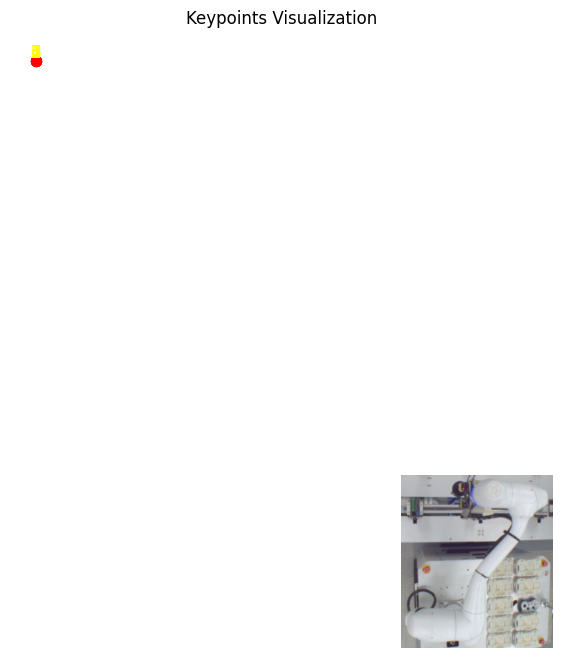

In [31]:
image = Image.open(image_path)

plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.scatter(output[:, 0], output[:, 1], c='red', s=50, label='Keypoints')

for i, (x, y) in enumerate(output):
    plt.text(x, y, str(i + 1), color='yellow', fontsize=12, ha='center', va='bottom')

connection_pairs = [
    (0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6)  # 예시로 연결 정의
]

for start, end in connection_pairs:
    x_coords = [output[start, 0], output[end, 0]]
    y_coords = [output[start, 1], output[end, 1]]
    plt.plot(x_coords, y_coords, c='blue', linewidth=2)  # 파란 선으로 연결

plt.title("Keypoints Visualization")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.axis('off') 
plt.show()

In [32]:
json_file_path = "/home/najo/NAS/DIP/datasets/DREAM/data/real/panda-3cam_realsense/panda-3cam_realsense/000000.json"

with open(json_file_path, 'r') as f:
    json_data = json.load(f)

gt_output = np.array([
    keypoint["location"][0:3] for keypoint in json_data["objects"][0]["keypoints"]
])

# 깊이 값 (Z) - 각 픽셀 좌표에 대응하는 깊이 정보
depth_values = np.array([
    keypoint["location"][2] for keypoint in json_data["objects"][0]["keypoints"]
])

camera_settings_file_path = "/home/najo/NAS/DIP/datasets/DREAM/data/real/panda-3cam_realsense/panda-3cam_realsense/_camera_settings.json"

with open(camera_settings_file_path, 'r') as f:
    camera_settings = json.load(f)

# 카메라 파라미터 추출
intrinsics = camera_settings["camera_settings"][0]["intrinsic_settings"]
fx = intrinsics["fx"]
fy = intrinsics["fy"]
cx = intrinsics["cx"]
cy = intrinsics["cy"]

K = np.array([[fx, 0, cx],
              [0, fy, cy],
              [0, 0, 1]])

camera_coordinates = []
for i, pt in enumerate(output):
    x_pixel, y_pixel = pt
    z_depth = depth_values[i] if i < len(depth_values) else depth_values  # 깊이값 사용 또는 기본값 사용
    x_camera = (x_pixel - cx) * z_depth / fx
    y_camera = (y_pixel - cy) * z_depth / fy
    camera_coordinates.append([x_camera, y_camera])

camera_coordinates = np.array(camera_coordinates)

In [33]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 데이터셋 정의
class JointDepthDataset(Dataset):
    def __init__(self, json_dir, transform=None):
        self.json_dir = json_dir
        self.exclude_file = "_camera_settings.json"
        self.file_list = [f for f in os.listdir(json_dir) if f.endswith('.json') and f != self.exclude_file]
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        json_path = os.path.join(self.json_dir, self.file_list[idx])
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        # JSON 데이터에서 x, y 좌표와 depth 추출
        inputs = np.array([keypoint["location"][0:2] for keypoint in data["objects"][0]["keypoints"]])
        depth = np.array([keypoint["location"][2] for keypoint in data["objects"][0]["keypoints"]])
        
        # 텐서 변환
        inputs = torch.tensor(inputs, dtype=torch.float32)
        targets = torch.tensor(depth, dtype=torch.float32)
        
        # 전처리 적용 (선택 사항)
        if self.transform:
            inputs, targets = self.transform(inputs, targets)
        
        return inputs, targets

# 데이터셋 초기화
dataset = JointDepthDataset(json_dir='/home/najo/NAS/DIP/datasets/DREAM/data/real/panda-3cam_realsense/panda-3cam_realsense')
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

# 모델 정의
class MultiLabelDepthPredictor(nn.Module):
    def __init__(self):
        super(MultiLabelDepthPredictor, self).__init__()
        self.joint_net = nn.Sequential(
            nn.Linear(2, 32),  # (x, y) -> 히든 레이어 32
            nn.ReLU(),
            nn.Linear(32, 16),  # 히든 레이어 32 -> 16
            nn.ReLU(),
            nn.Linear(16, 1)    # 최종 출력 -> depth (스칼라)
        )
    
    def forward(self, x):
        batch_size, num_joints, _ = x.size()
        outputs = []
        for i in range(num_joints):
            joint_input = x[:, i, :]  # (batch_size, 2)
            joint_output = self.joint_net(joint_input)  # (batch_size, 1)
            outputs.append(joint_output)
        
        outputs = torch.cat(outputs, dim=1)  # (batch_size, 7)
        return outputs

# 모델 초기화
model = MultiLabelDepthPredictor().to(device)

# 손실 함수와 옵티마이저 설정
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습 루프
epochs = 50
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    
    for inputs, targets in dataloader:
        # 데이터 GPU로 이동
        inputs = inputs.to(device)
        targets = targets.to(device)

        # Forward pass
        predictions = model(inputs)
        loss = criterion(predictions, targets)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    # 에포크별 평균 손실 출력
    if (epoch + 1) % 10 == 0:  # 10 에포크마다 출력
        print(f"Epoch [{epoch + 1}/{epochs}], Average Loss: {epoch_loss / len(dataloader):.4f}")


Using device: cuda
Epoch [10/50], Average Loss: 0.0572
Epoch [20/50], Average Loss: 0.0115
Epoch [30/50], Average Loss: 0.0112
Epoch [40/50], Average Loss: 0.0108
Epoch [50/50], Average Loss: 0.0105


ground_truth :
 [[    0.19787     0.43385      1.3987]
 [    0.17972     0.10844      1.3303]
 [    0.38098     -0.1099      1.4384]
 [    0.33592    -0.16909      1.4027]
 [   0.010271   -0.086852      1.1991]
 [  -0.062766   -0.080975      1.1504]
 [   -0.06468     0.02486       1.166]]

model_predict :
 [[     3.7611      4.9152       3.999]
 [     3.5773      4.6987      3.8036]
 [     3.8678       5.041      4.1125]
 [     3.7719       4.928      4.0105]
 [     3.2244      4.2831      3.4284]
 [     3.0934      4.1325       3.289]
 [     3.1354      4.1801      3.3337]]

각 키포인트에 대한 오차 (m):
[     6.9057      6.3847      6.8594      6.6377      5.5803      5.3263      5.4584]

평균 오차 (m):
6.164665981662384

오차의 표준편차 (m):
0.6377480067180501


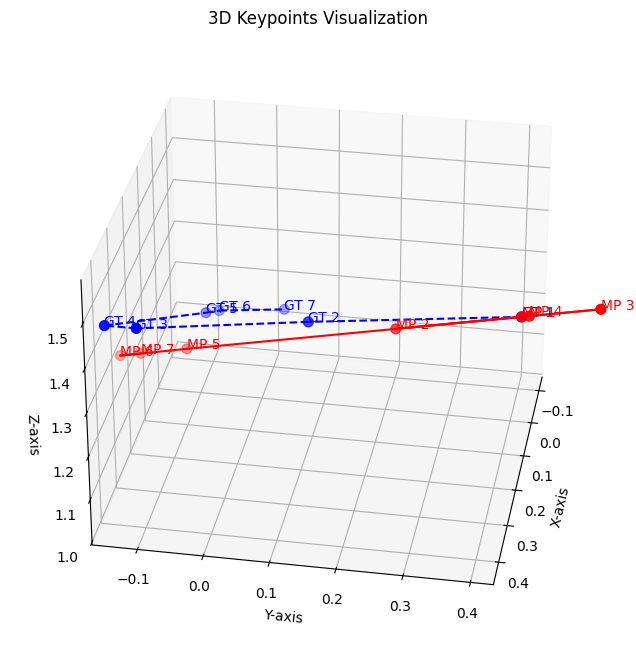

In [35]:
# 테스트
with torch.no_grad():
    model.eval()
    test_input = torch.tensor(camera_coordinates, dtype=torch.float32).unsqueeze(0).to(device)  # (1, 7, 2)
    
    # 테스트 결과
    test_output = model(test_input)  # (1, 7)

    test_input = test_input.cpu().numpy()
    test_output = test_output.cpu().numpy()

output_coordinates = []

for i in range(test_input.shape[1]):  # 7개 좌표에 대해 반복
    x, y = test_input[0, i]
    z = test_output[0, i]
    output_coordinates.append([x, y, z])

# 결과 출력
keypoints_3d = -np.array(output_coordinates)

# X축 기준 90도 회전 행렬
theta = np.pi / 2  # 90 degrees in radians
rotation_matrix_x = np.array([
    [1, 0, 0],
    [0, np.cos(theta), -np.sin(theta)],
    [0, np.sin(theta), np.cos(theta)]
])

keypoints_3d = keypoints_3d @ rotation_matrix_x.T
# gt_output = gt_output @ rotation_matrix_x.T

translation_vector = gt_output[0] - keypoints_3d[0]
aligned_keypoints_3d = keypoints_3d + translation_vector

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot ground truth
ax.scatter(gt_output[:, 0], gt_output[:, 1], gt_output[:, 2], c='blue', s=50, label='Ground Truth')
for i, (x, y, z) in enumerate(gt_output):
    ax.text(x, y, z, f'GT {i + 1}', color='blue')

# Plot model predictions
ax.scatter(aligned_keypoints_3d[:, 0], aligned_keypoints_3d[:, 1], aligned_keypoints_3d[:, 2], c='red', s=50, label='Model Prediction')
for i, (x, y, z) in enumerate(aligned_keypoints_3d):
    ax.text(x, y, z, f'MP {i + 1}', color='red')

connection_pairs = [
    (0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6)  # 예: 키포인트 인덱스 간 연결
]

# Draw connections for ground truth
for start, end in connection_pairs:
    x_coords = [gt_output[start, 0], gt_output[end, 0]]
    y_coords = [gt_output[start, 1], gt_output[end, 1]]
    z_coords = [gt_output[start, 2], gt_output[end, 2]]
    ax.plot(x_coords, y_coords, z_coords, c='blue', linestyle='--', label='GT Connections' if start == 0 else "")

# Draw connections for model predictions
for start, end in connection_pairs:
    x_coords = [aligned_keypoints_3d[start, 0], aligned_keypoints_3d[end, 0]]
    y_coords = [aligned_keypoints_3d[start, 1], aligned_keypoints_3d[end, 1]]
    z_coords = [aligned_keypoints_3d[start, 2], aligned_keypoints_3d[end, 2]]
    ax.plot(x_coords, y_coords, z_coords, c='red', label='MP Connections' if start == 0 else "")


ax.set_title("3D Keypoints Visualization")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")

# 동일한 스케일로 고정
max_range = np.array([
    gt_output[:, 0].max() - gt_output[:, 0].min(),
    gt_output[:, 1].max() - gt_output[:, 1].min(),
    gt_output[:, 2].max() - gt_output[:, 2].min()
]).max() / 2.0

mid_x = (gt_output[:, 0].max() + gt_output[:, 0].min()) * 0.5
mid_y = (gt_output[:, 1].max() + gt_output[:, 1].min()) * 0.5
mid_z = (gt_output[:, 2].max() + gt_output[:, 2].min()) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

ax.view_init(elev=30, azim=10)

print("ground_truth :\n", gt_output)
print("\nmodel_predict :\n", np.array(keypoints_3d))

# 두 좌표 세트 간의 유클리드 거리 계산
distances = np.linalg.norm(gt_output - output_coordinates, axis=1)

# 각 키포인트에 대한 오차 출력
print("\n각 키포인트에 대한 오차 (m):")
print(distances)

# 평균 오차 계산
mean_error = np.mean(distances)
print("\n평균 오차 (m):")
print(mean_error)

# 전체 오차의 표준편차 계산
std_error = np.std(distances)
print("\n오차의 표준편차 (m):")
print(std_error)

plt.show()